# Graph Neural Network

### Load Libraries

In [7]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from tqdm import tqdm
import optuna
from optuna.samplers import TPESampler

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

os.chdir("/home/jovyan/ds-project-2025/code/model")
print("Current working directory:", os.getcwd())

# Path setup — works whether launched from code/ or code/model/
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
if os.path.exists("code"):
    sys.path.append("code")

from src.data import (
    create_temp_graph_data_dict,
    normalize_graph_data,
    normalize_temp_graph_data,
)
from src.training import EarlyStopping, train_temporal_gnn
from src.evaluation import evaluation, evaluate_temporal_gnn


Using device: cuda
Current working directory: /home/jovyan/ds-project-2025/code/model


## Load Data

In [2]:
# create_temp_graph_data_dict produces a fixed-node graph for every year.
# Every Data object has the same num_nodes = len(global IPC mapping).
# Inactive nodes are zero-padded; data.node_available flags which are real.

# Year splits
train_years = list(range(2006, 2016))  # 10 years
val_years = list(range(2016, 2019))  # 3 years
test_years = list(range(2019, 2023))  # 4 years

data_dict = create_temp_graph_data_dict(
    data_folder="../data/ipc_mean_year_abstract",
    db_path="../data/patent.db",
    score_type="rel",
)
print(f"\nLoaded data for {len(data_dict)} years: {sorted(data_dict.keys())}")

data_dict, norm_stats = normalize_temp_graph_data(data_dict, train_years)

Calculating popularity scores...
Creating global IPC mapping...
Total unique IPC codes: 1989
Creating edgelist with Salton similarity...


Processing years for temporal graph: 100%|██████████| 17/17 [00:13<00:00,  1.30it/s]



Loaded data for 17 years: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Normalization fitted on 10 training year(s).
  count   mean=[83.68548583984375, 73.51998901367188], std=[129.19459533691406, 126.07595825195312]
  weight  mean=[4.297879695892334, 3.2306504249572754, 0.1480749249458313], std=[11.441514015197754, 11.152114868164062, 4.799782752990723]


In [3]:
sample_year = 2008
d = data_dict[sample_year]
print(f"Year {sample_year}")
print(f"  Total nodes (global IPC):   {d.x.shape[0]}")
print(f"  Embedding dim (x):          {d.x.shape[1]}")
print(
    f"  Scalar features:            {d.scalar.shape[1]}  (5 stats + 8 one-hot IPC category)"
)
print(f"  Edge index shape:           {d.edge_index.shape}")
print(f"  Edge attr shape:            {d.edge_attr.shape}")
print(f"  Target shape:               {d.y.shape}")
print(f"  Active nodes (available):   {d.node_available.sum().item()} / {d.x.shape[0]}")
print(f"  Inactive (zero-padded):     {(~d.node_available).sum().item()}")

Year 2008
  Total nodes (global IPC):   1989
  Embedding dim (x):          1024
  Scalar features:            12  (5 stats + 8 one-hot IPC category)
  Edge index shape:           torch.Size([2, 13607])
  Edge attr shape:            torch.Size([13607, 6])
  Target shape:               torch.Size([1989])
  Active nodes (available):   934 / 1989
  Inactive (zero-padded):     1055


## Year Splits & Feature Dimensions

In [4]:
print(f"Train: {train_years}")
print(f"Val:   {val_years}")
print(f"Test:  {test_years}")

# Feature dimensions (read from any loaded year)
_s = data_dict[2008]
NUM_NODES = _s.x.shape[0]
EMBEDDING_DIM = _s.x.shape[1]
SCALAR_DIM = _s.scalar.shape[1]  # 13 = 5 stats + 8 one-hot IPC category
EDGE_DIM = _s.edge_attr.shape[1]  # 6 temporal edge features

print(f"\nGlobal node count : {NUM_NODES}")
print(f"Embedding dim     : {EMBEDDING_DIM}")
print(f"Scalar dim        : {SCALAR_DIM}")
print(f"Edge feature dim  : {EDGE_DIM}")
print(f"Total node input  : {EMBEDDING_DIM + SCALAR_DIM}")

Train: [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]
Val:   [2016, 2017, 2018]
Test:  [2019, 2020, 2021, 2022]

Global node count : 1989
Embedding dim     : 1024
Scalar dim        : 12
Edge feature dim  : 6
Total node input  : 1036


## Model Definition — TemporalGATGRU (Enhanced)

In [5]:
class TemporalGATGRU(nn.Module):
    def __init__(
        self,
        embedding_dim: int,
        scalar_dim: int,
        edge_dim: int = 6,
        hidden_channels: int = 256,
        gat_heads: int = 8,
        num_gat_layers: int = 3,
        num_gru_layers: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.dropout = dropout
        self.num_gat_layers = num_gat_layers
        self.num_gru_layers = num_gru_layers
        node_in = embedding_dim + scalar_dim

        self.node_proj = nn.Sequential(
            nn.Linear(node_in, hidden_channels * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels * 2, hidden_channels),
        )

        self.gat_layers = nn.ModuleList(
            [
                GATConv(
                    in_channels=hidden_channels,
                    out_channels=hidden_channels,
                    heads=gat_heads,
                    concat=False,
                    dropout=dropout,
                    edge_dim=edge_dim,
                )
                for _ in range(num_gat_layers)
            ]
        )
        self.gat_norms = nn.ModuleList(
            [nn.LayerNorm(hidden_channels) for _ in range(num_gat_layers)]
        )

        self.gru_layers = nn.ModuleList(
            [
                nn.GRUCell(hidden_channels, hidden_channels)
                for _ in range(num_gru_layers)
            ]
        )
        self.gru_norms = nn.ModuleList(
            [nn.LayerNorm(hidden_channels) for _ in range(num_gru_layers)]
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, hidden_channels // 4),
            nn.ReLU(),
            nn.Linear(hidden_channels // 4, 1),
        )

    def forward(self, data, h):
        avail = data.node_available.unsqueeze(1).float()  # [N, 1]

        x = torch.cat([data.x, data.scalar], dim=1)
        x = self.node_proj(x)  # [N, H]

        for gat, norm in zip(self.gat_layers, self.gat_norms):
            residual = x
            x = gat(x, data.edge_index, data.edge_attr)  # [N, H]
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = norm(x + residual)  # residual add

        # Stacked GRU temporal update
        h_next = []
        inp = x
        for i, (gru, norm) in enumerate(zip(self.gru_layers, self.gru_norms)):
            h_i = gru(inp, h[i])
            h_i = norm(h_i)
            h_i = h_i * avail
            h_next.append(h_i)
            inp = h_i

        out = self.head(h_next[-1])  # [N, 1]
        return out, h_next

    def init_hidden(self, num_nodes: int, device) -> list:
        return [
            torch.zeros(num_nodes, self.hidden_channels, device=device)
            for _ in range(self.num_gru_layers)
        ]

Output shape:        torch.Size([1989, 1])   (expected [1989, 1])
GRU layers:          2
Hidden state[0]:     torch.Size([1989, 64])  (expected [1989, 64])
Hidden state[1]:     torch.Size([1989, 64])  (expected [1989, 64])
Max abs value of inactive hidden[0]: 0.000000  (expected ~0.0)


### Overfit Test

In [11]:
# Confirm dimensionality before the overfit test
_d = data_dict[2008]
print(f"num_node_features (x):  {_d.num_node_features}")
print(f"scalar shape:           {_d.scalar.shape}")
print(f"edge_attr shape:        {_d.edge_attr.shape}")
print(f"node_available dtype:   {_d.node_available.dtype}")
print(f"active nodes in 2008:   {_d.node_available.sum().item()}")

num_node_features (x):  1024
scalar shape:           torch.Size([1989, 12])
edge_attr shape:        torch.Size([13607, 6])
node_available dtype:   torch.bool
active nodes in 2008:   934


In [14]:
# Use a small 3-year window for both train and val so the model
# can easily memorise it — if it can't overfit, something is wrong.
overfit_train_years = [2013, 2014, 2015]
overfit_val_years = [2013, 2014, 2015]  # same data, just checking no NaN

overfit_model = TemporalGATGRU(
    embedding_dim=EMBEDDING_DIM,
    scalar_dim=SCALAR_DIM,
    edge_dim=EDGE_DIM,
    hidden_channels=64,
    gat_heads=1,
    dropout=0.0,
).to(device)

overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=0.005)
overfit_criterion = nn.MSELoss()

overfit_stopper = EarlyStopping(
    patience=200,
    min_delta=1e-6,
    path="gnn_overfit_test.pt",
    printing=False,
)

overfit_train_losses, _ = train_temporal_gnn(
    model=overfit_model,
    optimizer=overfit_optimizer,
    criterion=overfit_criterion,
    data_dict=data_dict,
    train_years=overfit_train_years,
    val_years=overfit_val_years,
    early_stopper=overfit_stopper,
    device=device,
    epochs=200,
    printing=True,
)

OVERFIT TEST — Pipeline Verification
Goal: loss should drop close to 0 within ~100 epochs
Epoch    1/200  Train: 0.10446  Val: 0.09711
Epoch    2/200  Train: 0.08922  Val: 0.08785
Epoch    3/200  Train: 0.08773  Val: 0.08555
Epoch    4/200  Train: 0.08615  Val: 0.08672
Epoch    5/200  Train: 0.08532  Val: 0.08509
Epoch    6/200  Train: 0.08546  Val: 0.08507
Epoch    7/200  Train: 0.08478  Val: 0.08486
Epoch    8/200  Train: 0.08490  Val: 0.08478
Epoch    9/200  Train: 0.08474  Val: 0.08450
Epoch   10/200  Train: 0.08470  Val: 0.08448
Epoch   11/200  Train: 0.08435  Val: 0.08445
Epoch   12/200  Train: 0.08446  Val: 0.08443
Epoch   13/200  Train: 0.08445  Val: 0.08431
Epoch   14/200  Train: 0.08444  Val: 0.08432
Epoch   15/200  Train: 0.08427  Val: 0.08431
Epoch   16/200  Train: 0.08435  Val: 0.08433
Epoch   17/200  Train: 0.08440  Val: 0.08429
Epoch   18/200  Train: 0.08436  Val: 0.08429
Epoch   19/200  Train: 0.08429  Val: 0.08429
Epoch   20/200  Train: 0.08431  Val: 0.08430
Epoch   21

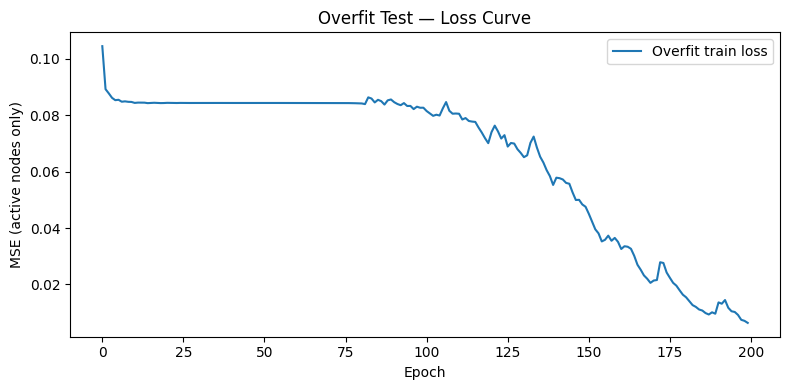

Final overfit loss: 0.006387


In [15]:
# Plot the overfit training curve to visually confirm convergence
plt.figure(figsize=(8, 4))
plt.plot(overfit_train_losses, label="Overfit train loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (active nodes only)")
plt.title("Overfit Test — Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Final overfit loss: {overfit_train_losses[-1]:.6f}")

Overfit checkpoint loaded.

MODEL: TemporalGATGRU
Number of predictions:            3349
Mean Squared Error (MSE):         0.031084
Root Mean Squared Error (RMSE):   0.176306
Mean Absolute Error (MAE):        0.122423
Median Absolute Error:            0.086716
Mean Absolute Percentage Error:   27292486.83%
R² Score:                         0.644248

BASELINE: Previous Year's Score (Persistence)
Number of predictions:            3249
Mean Squared Error (MSE):         0.300560
Root Mean Squared Error (RMSE):   0.548234
Mean Absolute Error (MAE):        0.389572
Median Absolute Error:            0.294495
Mean Absolute Percentage Error:   81601426.52%
R² Score:                         -2.483028

BASELINE: Overall Mean (Global Historical Mean)
Number of predictions:            5967
Mean Squared Error (MSE):         0.049192
Root Mean Squared Error (RMSE):   0.221793
Mean Absolute Error (MAE):        0.134041
Median Absolute Error:            0.034822
Mean Absolute Percentage Error:   769911

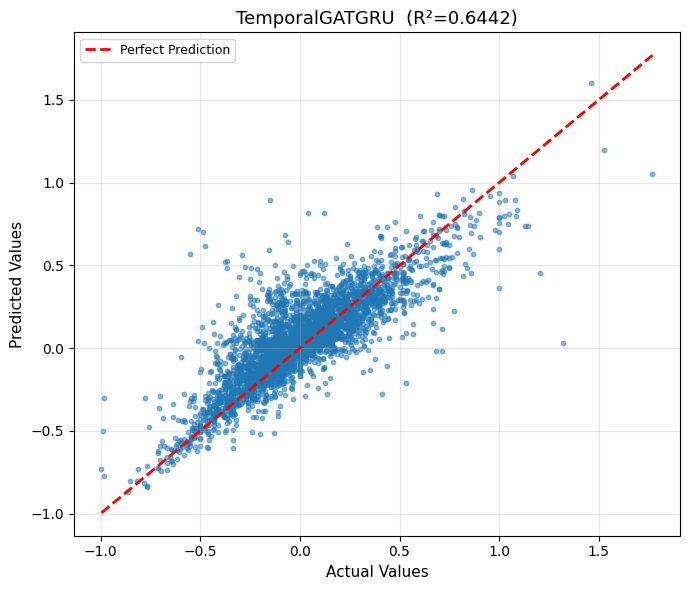

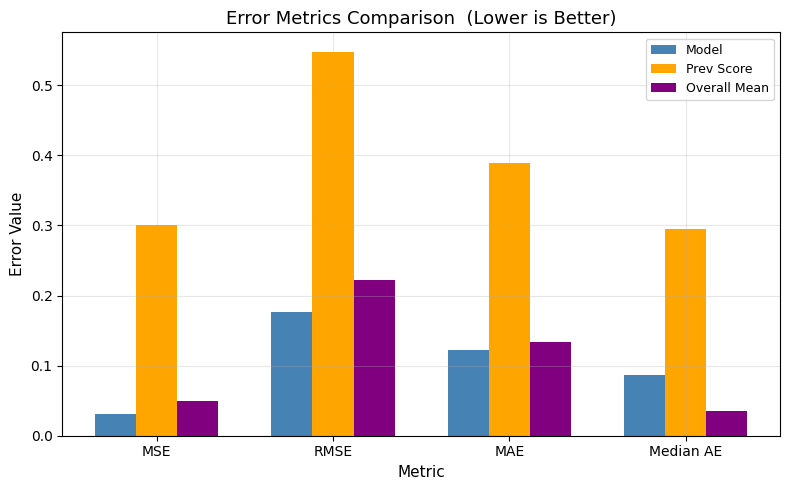

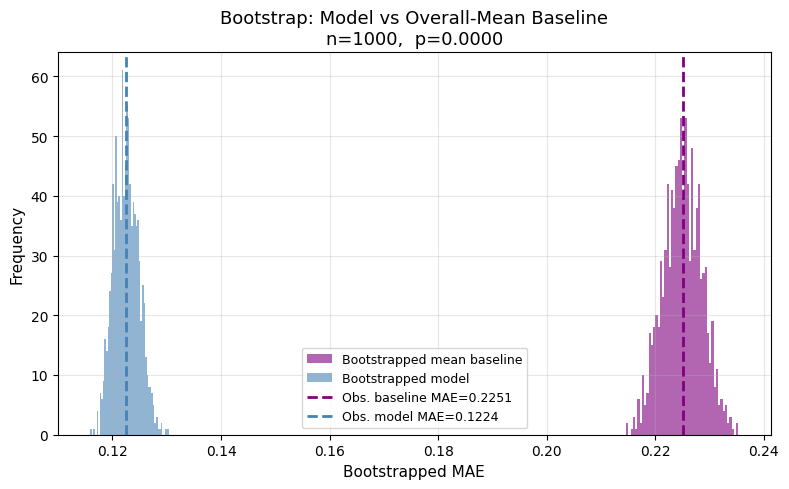

In [ ]:
# Evaluate the overfit model on the same years it was trained on.
# train_years / val_years drive the GRU warm-up; test_years are where
# predictions are collected.  Using the same 3-year window for all three
# verifies that the model has memorised the data and that the evaluation
# pipeline is bug-free.

overfit_model.load_state_dict(torch.load("gnn_overfit_test.pt", map_location=device))
print("Overfit checkpoint loaded.")

overfit_results = evaluate_temporal_gnn(
    model=overfit_model,
    data_dict=data_dict,
    train_years=overfit_train_years,  # warm-up  (2013-2015)
    val_years=[],  # no separate val warm-up needed
    test_years=overfit_train_years,  # evaluate on the same 3 years
    device=device,
    printing=True,
    compare_baselines=True,
    export=True,
    export_dir="temporal_gnn",
)


### Single Setup Training

Removing existing model at: best_temporal_gat_gru.pt
Model parameters: 3,191,809

Starting full training...
Epoch    1/500  Train: 0.07553  Val: 0.07099
Validation loss decreased (0.070994 --> 0.070994).  Saving model ...
Epoch    2/500  Train: 0.07390  Val: 0.07586
Epoch    3/500  Train: 0.07347  Val: 0.07023
Validation loss decreased (0.070994 --> 0.070232).  Saving model ...
Epoch    4/500  Train: 0.07307  Val: 0.07335
Epoch    5/500  Train: 0.07268  Val: 0.07296
Epoch    6/500  Train: 0.07263  Val: 0.07360
Epoch    7/500  Train: 0.07263  Val: 0.07304
Epoch    8/500  Train: 0.07237  Val: 0.07204
Epoch    9/500  Train: 0.07216  Val: 0.07350
Epoch   10/500  Train: 0.07196  Val: 0.07292
Epoch   11/500  Train: 0.07187  Val: 0.07591
Epoch   12/500  Train: 0.07252  Val: 0.06898
Validation loss decreased (0.070232 --> 0.068980).  Saving model ...
Epoch   13/500  Train: 0.07292  Val: 0.07836
Epoch   14/500  Train: 0.07291  Val: 0.07031
Epoch   15/500  Train: 0.07228  Val: 0.07131
Epoch   16

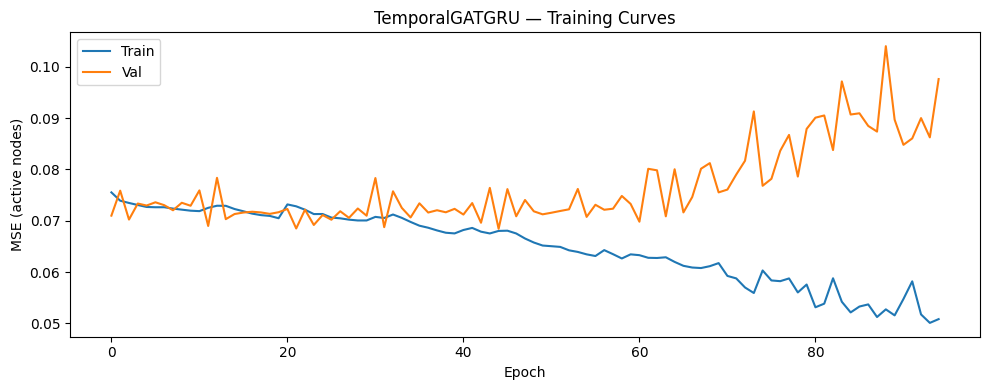


Best val loss: 0.06843


In [6]:
# ── Hyperparameters ───────────────────────────────────────────────────────
HIDDEN_CHANNELS = 256
GAT_HEADS = 8
NUM_GAT_LAYERS = 3
NUM_GRU_LAYERS = 2
DROPOUT = 0.2
LR = 1e-4
EPOCHS = 500

model = TemporalGATGRU(
    embedding_dim=EMBEDDING_DIM,
    scalar_dim=SCALAR_DIM,
    edge_dim=EDGE_DIM,
    hidden_channels=HIDDEN_CHANNELS,
    gat_heads=GAT_HEADS,
    num_gat_layers=NUM_GAT_LAYERS,
    num_gru_layers=NUM_GRU_LAYERS,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

early_stopper = EarlyStopping(
    patience=50,
    min_delta=1e-5,
    path="best_temporal_gat_gru.pt",
    printing=True,
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\nStarting full training...")

train_losses, val_losses = train_temporal_gnn(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    data_dict=data_dict,
    train_years=train_years,
    val_years=val_years,
    early_stopper=early_stopper,
    device=device,
    epochs=EPOCHS,
    printing=True,
)

# Loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="Train")
ax.plot(val_losses, label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (active nodes)")
ax.set_title("TemporalGATGRU — Training Curves")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBest val loss: {early_stopper.best_loss:.5f}")


### Hyperparameter Tuning Optuna

Starting Optuna search: 30 trials, up to 100 epochs each.


  0%|          | 0/30 [00:00<?, ?it/s]


Best trial: #1  (val loss = 0.212190)
Best hyperparameters:
  hidden_channels     : 448
  gat_heads           : 5
  num_gat_layers      : 3
  num_gru_layers      : 1
  dropout             : 0.4
  learning_rate       : 0.000462258900102083
  weight_decay        : 4.335281794951567e-06


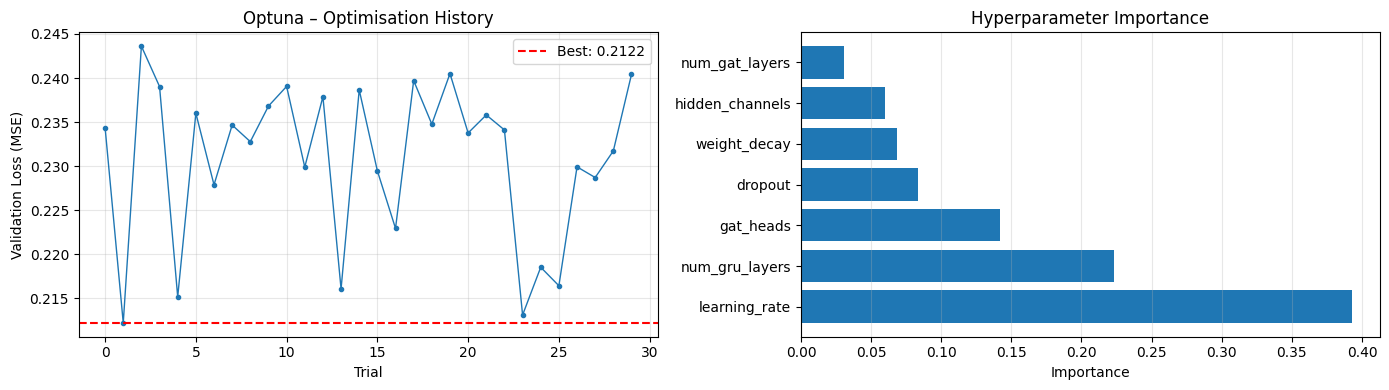


Retraining with best hyperparameters (full patience / epochs)…
Epoch    1/500  Train: 0.24453  Val: 0.25936
Validation loss decreased (0.259363 --> 0.259363).  Saving model ...
Epoch    2/500  Train: 0.24178  Val: 0.24968
Validation loss decreased (0.259363 --> 0.249680).  Saving model ...
Epoch    3/500  Train: 0.23989  Val: 0.24359
Validation loss decreased (0.249680 --> 0.243590).  Saving model ...
Epoch    4/500  Train: 0.23907  Val: 0.25371
Epoch    5/500  Train: 0.23922  Val: 0.24581
Epoch    6/500  Train: 0.23771  Val: 0.25033
Epoch    7/500  Train: 0.23797  Val: 0.24865
Epoch    8/500  Train: 0.23639  Val: 0.24357
Validation loss decreased (0.243590 --> 0.243575).  Saving model ...
Epoch    9/500  Train: 0.23564  Val: 0.25166
Epoch   10/500  Train: 0.23687  Val: 0.23708
Validation loss decreased (0.243575 --> 0.237077).  Saving model ...
Epoch   11/500  Train: 0.23411  Val: 0.23877
Epoch   12/500  Train: 0.23347  Val: 0.24764
Epoch   13/500  Train: 0.23319  Val: 0.25848
Epoch 

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

# ── Optuna Hyperparameter Tuning ──────────────────────────────────────────────
# Hyperparameters searched:
#   hidden_channels  : width of internal GAT / GRU layers
#   gat_heads        : number of attention heads
#   num_gat_layers   : number of stacked GATConv layers
#   num_gru_layers   : number of stacked GRUCell layers
#   dropout          : dropout rate
#   learning_rate    : Adam LR
#   weight_decay     : Adam L2 regularisation

N_TRIALS = 30  # increase for a more thorough search
MAX_EPOCHS = 100  # epochs per trial (early-stopping can cut this short)
PATIENCE = 15  # early-stopping patience during tuning


def objective(trial: optuna.Trial) -> float:
    """Return best validation loss for a given set of hyperparameters."""

    # ── Sample hyperparameters ────────────────────────────────────────────────
    hidden_channels = trial.suggest_int("hidden_channels", 64, 512, step=64)
    gat_heads = trial.suggest_int("gat_heads", 1, 8)
    num_gat_layers = trial.suggest_int("num_gat_layers", 1, 4)
    num_gru_layers = trial.suggest_int("num_gru_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.4, step=0.1)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    # ── Build model ───────────────────────────────────────────────────────────
    _model = TemporalGATGRU(
        embedding_dim=EMBEDDING_DIM,
        scalar_dim=SCALAR_DIM,
        edge_dim=EDGE_DIM,
        hidden_channels=hidden_channels,
        gat_heads=gat_heads,
        num_gat_layers=num_gat_layers,
        num_gru_layers=num_gru_layers,
        dropout=dropout,
    ).to(device)

    _optimizer = optim.Adam(
        _model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    _criterion = nn.L1Loss()

    # Use a trial-specific checkpoint path so parallel trials don't collide
    ckpt_path = f"optuna_temporal_trial_{trial.number}.pt"
    _early_stopper = EarlyStopping(
        patience=PATIENCE,
        min_delta=1e-5,
        path=ckpt_path,
        printing=False,  # suppress per-epoch output during tuning
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    train_temporal_gnn(
        model=_model,
        optimizer=_optimizer,
        criterion=_criterion,
        data_dict=data_dict,
        train_years=train_years,
        val_years=val_years,
        early_stopper=_early_stopper,
        device=device,
        epochs=MAX_EPOCHS,
        printing=False,
    )

    best_val_loss = _early_stopper.best_loss

    # Report to Optuna and allow pruning at the end of training
    trial.report(best_val_loss, step=MAX_EPOCHS)

    # Clean up the checkpoint file
    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)

    return best_val_loss


# ── Run study ─────────────────────────────────────────────────────────────────
sampler = TPESampler(seed=42)
study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    study_name="GNN Temp",
    storage="sqlite:///gnn_temp.db",
    load_if_exists=False,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep output clean

print(f"Starting Optuna search: {N_TRIALS} trials, up to {MAX_EPOCHS} epochs each.")
print("=" * 60)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

# ── Results ───────────────────────────────────────────────────────────────────
best = study.best_trial
print("\n" + "=" * 60)
print(f"Best trial: #{best.number}  (val loss = {best.value:.6f})")
print("Best hyperparameters:")
for k, v in best.params.items():
    print(f"  {k:20s}: {v}")

# Store best params for easy access in subsequent cells
best_params = best.params

# ── Plot optimisation history ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimisation history
values = [t.value for t in study.trials]
axes[0].plot(values, marker="o", linewidth=1, markersize=3)
axes[0].axhline(best.value, color="r", linestyle="--", label=f"Best: {best.value:.4f}")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation Loss (MSE)")
axes[0].set_title("Optuna – Optimisation History")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter importance (requires scikit-learn)
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()))
    axes[1].set_xlabel("Importance")
    axes[1].set_title("Hyperparameter Importance")
    axes[1].grid(True, alpha=0.3, axis="x")
except Exception:
    axes[1].text(
        0.5,
        0.5,
        "Install scikit-learn\nfor importance plot",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
    )

plt.tight_layout()
plt.show()



Retraining with best hyperparameters (full patience / epochs)…
Removing existing model at: pt_models/best_gnn_temp.pt
Epoch    1/500  Train: 0.24469  Val: 0.24372
Validation loss decreased (0.243716 --> 0.243716).  Saving model ...
Epoch    2/500  Train: 0.24030  Val: 0.25886
Epoch    3/500  Train: 0.24133  Val: 0.25179
Epoch    4/500  Train: 0.24006  Val: 0.24427
Epoch    5/500  Train: 0.23847  Val: 0.27241
Epoch    6/500  Train: 0.24189  Val: 0.24157
Validation loss decreased (0.243716 --> 0.241565).  Saving model ...
Epoch    7/500  Train: 0.23857  Val: 0.24631
Epoch    8/500  Train: 0.23802  Val: 0.25229
Epoch    9/500  Train: 0.23796  Val: 0.25100
Epoch   10/500  Train: 0.23700  Val: 0.24326
Epoch   11/500  Train: 0.23510  Val: 0.24603
Epoch   12/500  Train: 0.23589  Val: 0.24777
Epoch   13/500  Train: 0.23474  Val: 0.24433
Epoch   14/500  Train: 0.23261  Val: 0.24408
Epoch   15/500  Train: 0.23210  Val: 0.25299
Epoch   16/500  Train: 0.23170  Val: 0.25786
Epoch   17/500  Train: 

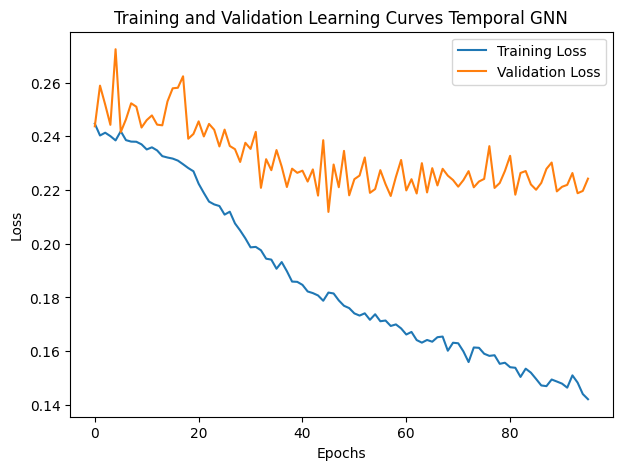


Best Optuna val loss: 0.21184


In [8]:
study = optuna.load_study(
    study_name="GNN Temp",
    storage="sqlite:///gnn_temp.db",
)
best_params = study.best_params

# ── Retrain with best hyperparameters ─────────────────────────────────────────
print("\nRetraining with best hyperparameters (full patience / epochs)…")

best_model = TemporalGATGRU(
    embedding_dim=EMBEDDING_DIM,
    scalar_dim=SCALAR_DIM,
    edge_dim=EDGE_DIM,
    hidden_channels=best_params["hidden_channels"],
    gat_heads=best_params["gat_heads"],
    num_gat_layers=best_params["num_gat_layers"],
    num_gru_layers=best_params["num_gru_layers"],
    dropout=best_params["dropout"],
).to(device)

best_optimizer = optim.Adam(
    best_model.parameters(),
    lr=best_params["learning_rate"],
    weight_decay=best_params["weight_decay"],
)
best_criterion = nn.L1Loss()
best_early_stopper = EarlyStopping(
    patience=50,
    min_delta=1e-5,
    path="pt_models/best_gnn_temp.pt",
    printing=True,
)

EPOCHS = 500

train_losses, val_losses = train_temporal_gnn(
    model=best_model,
    optimizer=best_optimizer,
    criterion=best_criterion,
    data_dict=data_dict,
    train_years=train_years,
    val_years=val_years,
    early_stopper=best_early_stopper,
    device=device,
    epochs=EPOCHS,
    printing=True,
)

# plot loss curves
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Learning Curves Temporal GNN")
plt.legend()
plt.show()

print(f"\nBest Optuna val loss: {best_early_stopper.best_loss:.5f}")

## Test Set Evaluation with Baseline Comparison


Best Optuna model loaded.

MODEL: TemporalGATGRU
Number of predictions:            5684
Mean Squared Error (MSE):         0.063542
Root Mean Squared Error (RMSE):   0.252076
Mean Absolute Error (MAE):        0.188671
Median Absolute Error:            0.148785
Mean Absolute Percentage Error:   26895140.06%
R² Score:                         0.271841

BASELINE: Previous Year's Score (Persistence)
Number of predictions:            4156
Mean Squared Error (MSE):         0.252137
Root Mean Squared Error (RMSE):   0.502133
Mean Absolute Error (MAE):        0.373026
Median Absolute Error:            0.281809
Mean Absolute Percentage Error:   52827555.36%
R² Score:                         -1.886821

BASELINE: Overall Mean (Global Historical Mean)
Number of predictions:            5684
Mean Squared Error (MSE):         0.088240
Root Mean Squared Error (RMSE):   0.297052
Mean Absolute Error (MAE):        0.226622
Median Absolute Error:            0.183740
Mean Absolute Percentage Error:   8466179

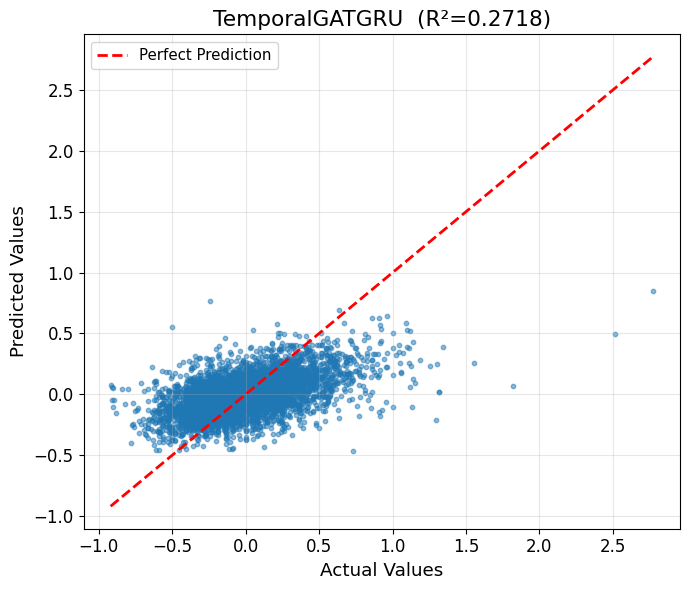

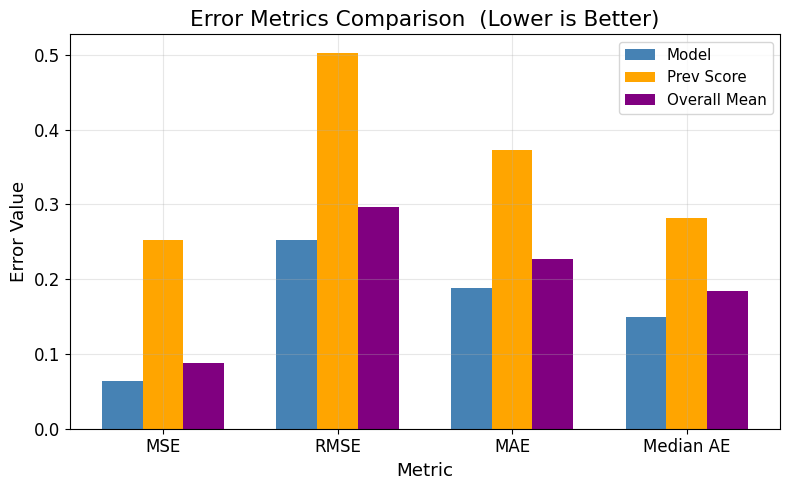

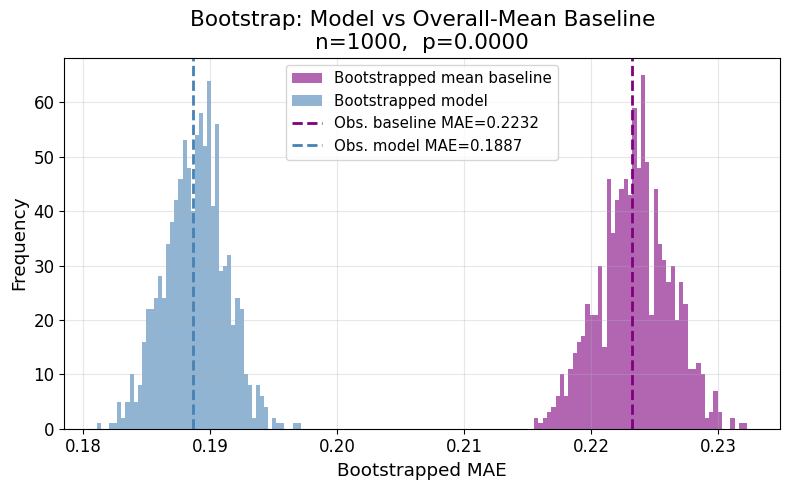

In [ ]:
study = optuna.load_study(
    study_name="GNN Temp",
    storage="sqlite:///gnn_temp.db",
)
best_params = study.best_params

best_model = TemporalGATGRU(
    embedding_dim=EMBEDDING_DIM,
    scalar_dim=SCALAR_DIM,
    edge_dim=EDGE_DIM,
    hidden_channels=best_params["hidden_channels"],
    gat_heads=best_params["gat_heads"],
    num_gat_layers=best_params["num_gat_layers"],
    num_gru_layers=best_params["num_gru_layers"],
    dropout=best_params["dropout"],
).to(device)

# ── Load best Optuna checkpoint ────────────────────────────────────────────
best_model.load_state_dict(
    torch.load("pt_models/best_gnn_temp.pt", map_location=device)
)
print("Best Optuna model loaded.")

# ── Evaluate with warmup + baseline comparison ─────────────────────────────
results = evaluate_temporal_gnn(
    model=best_model,
    data_dict=data_dict,
    train_years=train_years,
    val_years=val_years,
    test_years=test_years,
    device=device,
    printing=True,
    compare_baselines=True,
    export=True,
    export_dir="gnn_temp_exports",
    font_scale=1.2,
)

all_preds = results["model"]["predictions"]
all_targets = results["model"]["targets"]
all_years = results["model"]["years"]
model_metrics = results["model"]["metrics"]
ps_metrics = (
    results["prev_score_baseline"]["metrics"]
    if results["prev_score_baseline"]
    else None
)
pm_metrics = (
    results["overall_mean_baseline"]["metrics"]
    if results["overall_mean_baseline"]
    else None
)